In [95]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor, plot_importance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [50]:
data = pd.read_csv("/Users/alex/Library/CloudStorage/GoogleDrive-alex.yoon99@gmail.com/My Drive/Personal Projects/Doordash Delivery Prediction/datasets/historical_data.csv")
data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [65]:
data.isna().sum()

market_id                                         987
created_at                                          0
actual_delivery_time                                0
store_id                                            0
store_primary_category                            867
order_protocol                                    995
total_items                                         0
subtotal                                            0
num_distinct_items                                  0
min_item_price                                      0
max_item_price                                      0
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_order_place_duration                      0
estimated_store_to_consumer_driving_duration      526
delivery_time                                       0
non_prep_time                                     526
percent_busy_dashers        

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 19 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     196434 non-null  float64       
 1   created_at                                    197421 non-null  datetime64[ns]
 2   actual_delivery_time                          197421 non-null  datetime64[ns]
 3   store_id                                      197421 non-null  int64         
 4   store_primary_category                        196554 non-null  object        
 5   order_protocol                                196426 non-null  float64       
 6   total_items                                   197421 non-null  int64         
 7   subtotal                                      197421 non-null  int64         
 8   num_distinct_items                            197421 non-nu

In [ ]:
#drop where delivery_time is n/a
data.dropna(subset = ["delivery_time"], inplace= True)


In [68]:
#change time related variables to datetime
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])

#create new col delivery_time (total seconds from delivery to order)
data["delivery_time"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds()

#calculate nonprep time for delivery
data["non_prep_time"] = data["estimated_order_place_duration"] + data["estimated_store_to_consumer_driving_duration"]

In [73]:
#impute missing values for total_onshift_dashers, tota_busy_dashers
imputer= SimpleImputer(strategy="median")
data[["total_onshift_dashers", "total_busy_dashers"]] = imputer.fit_transform(data[["total_onshift_dashers", "total_busy_dashers"]])
#get percent of dashers who are busy
data["percent_busy_dashers"] = data["total_busy_dashers"] / (data["total_onshift_dashers"])

#replace infinate values with 0
data["percent_busy_dashers"] = data["percent_busy_dashers"].replace([np.inf, -np.inf], 0)

In [74]:
#add primary category for each restaurant by filling na with most common category
store_id_and_category = (
    data.groupby('store_id')['store_primary_category']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .to_dict()
)
data["store_primary_category"] = data["store_primary_category"].fillna(
    data["store_id"].map(store_id_and_category)
)

data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_time,non_prep_time,percent_busy_dashers
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,3779.0,1307.0,0.424242
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,4024.0,1136.0,2.000000
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,indian,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,1781.0,1136.0,0.000000
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,indian,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,3075.0,735.0,1.000000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,indian,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,2390.0,1096.0,1.000000


In [75]:
features = ['total_items',
       'num_distinct_items', 'estimated_order_place_duration',
       'estimated_store_to_consumer_driving_duration',
       'percent_busy_dashers', 'non_prep_time']

prediction = "delivery_time"

X = data[features]
y = data[prediction]


In [76]:
#onehotencode store_primary_cat
store_prim_dummie = pd.get_dummies(data["store_primary_category"], prefix="cat").astype(int)
store_prim_dummie

,cat_afghan,cat_african,cat_alcohol,cat_alcohol-plus-food,cat_american,cat_argentine,cat_asian,cat_barbecue,cat_belgian,cat_brazilian,...,cat_southern,cat_spanish,cat_steak,cat_sushi,cat_tapas,cat_thai,cat_turkish,cat_vegan,cat_vegetarian,cat_vietnamese
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197423,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197424,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197425,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197426,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
#concat OHE store_primary_cat and traindf
X = pd.concat([X, store_prim_dummie], axis = 1)
X.head()

,total_items,num_distinct_items,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,percent_busy_dashers,non_prep_time,cat_afghan,cat_african,cat_alcohol,cat_alcohol-plus-food,...,cat_southern,cat_spanish,cat_steak,cat_sushi,cat_tapas,cat_thai,cat_turkish,cat_vegan,cat_vegetarian,cat_vietnamese
0,4,4,446,861.0,0.424242,1307.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,446,690.0,2.000000,1136.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,446,690.0,0.000000,1136.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,5,446,289.0,1.000000,735.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,3,446,650.0,1.000000,1096.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


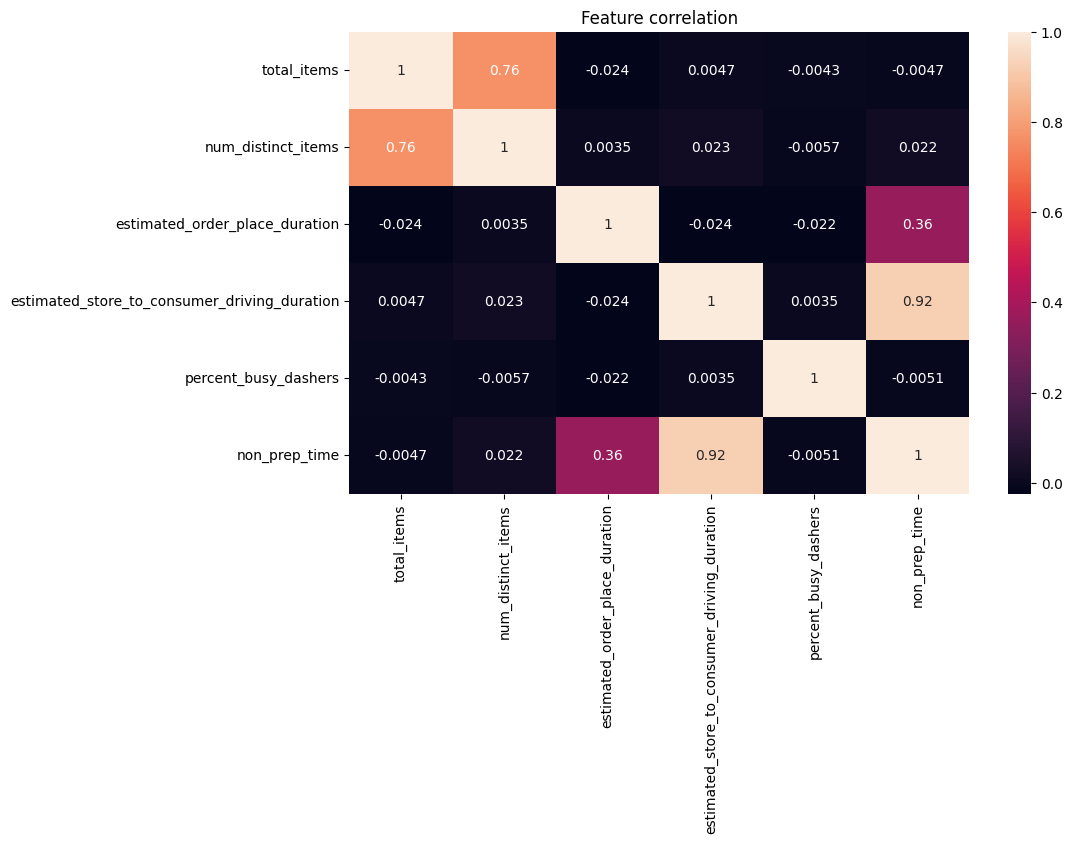

In [78]:
#ignoring OHE, find corr between feature columns
plt.figure(figsize=(10,6))
sns.heatmap(X[features].corr(), annot= True)
plt.title("Feature correlation")
plt.show()

In [79]:
#drop_total_items and non_prep_time. They are highly correlated
X_train.drop(["total_items", "non_prep_time"], axis = 1)
X_test.drop(["total_items", "non_prep_time"], axis = 1)


,num_distinct_items,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,percent_busy_dashers
175813,2,251,495.0,3.000000
79762,2,251,196.0,1.161290
80915,3,251,501.0,1.000000
155400,1,251,816.0,0.600000
78044,1,251,573.0,0.869565
...,...,...,...,...
132271,4,251,643.0,1.058824
70211,4,251,800.0,1.205128
173232,1,251,603.0,1.000000
123884,3,251,402.0,0.277778


In [ ]:
#create test split and fit model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)

xgb = XGBRegressor(n_estimators = 100,
                    learning_rate = 0.1,
                    max_depth = 5,
                    random_state= 42)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [87]:
#evaluate model
y_pred = xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 874.0825295397501
RMSE: 537924965.0216908


<Figure size 1200x800 with 0 Axes>

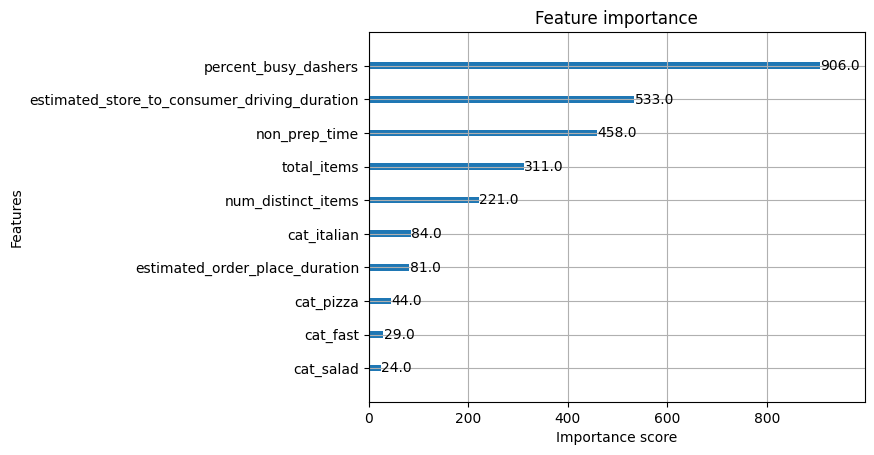

In [88]:
plt.figure(figsize=(12,8))

plot_importance(xgb, max_num_features= 10)
plt.show()

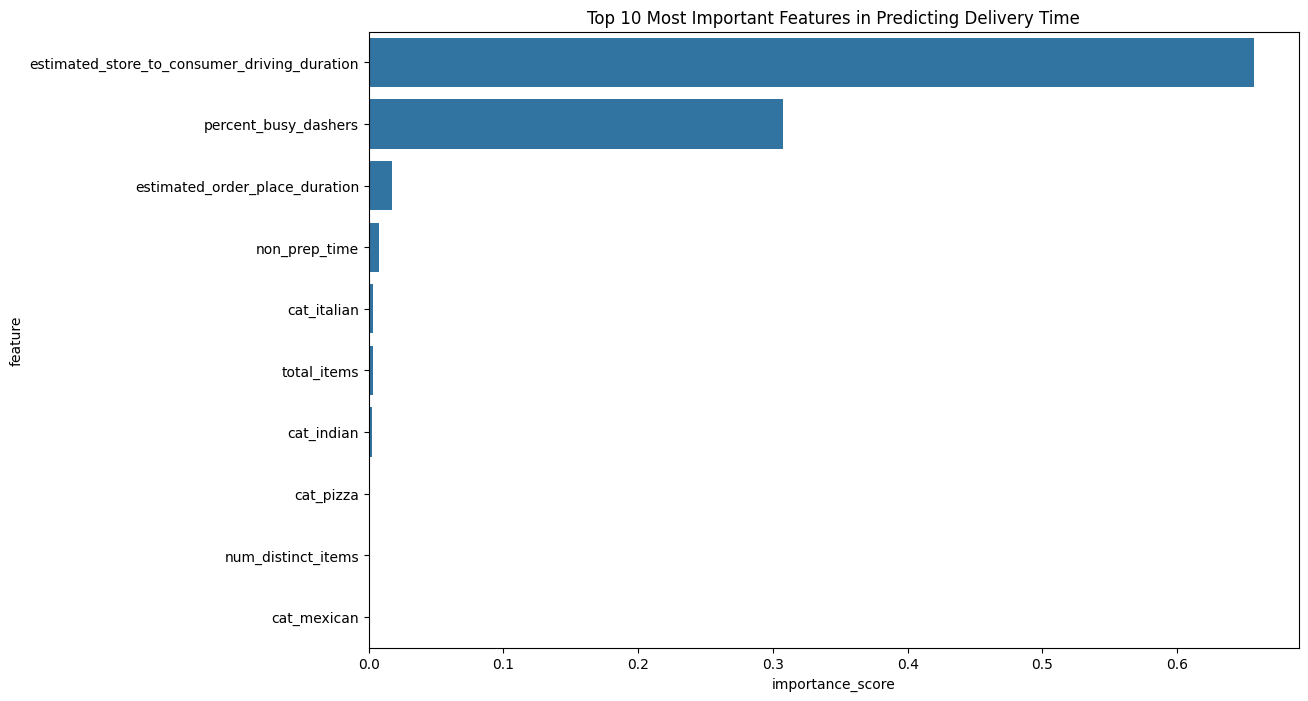

In [94]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance_score": xgb.feature_importances_
})

importance = importance.sort_values(by="importance_score", ascending = False)

plt.figure(figsize=(12,8))
sns.barplot(x="importance_score",
            y = "feature",
            data = importance.head(10))
plt.title("Top 10 Most Important Features in Predicting Delivery Time")
plt.show()

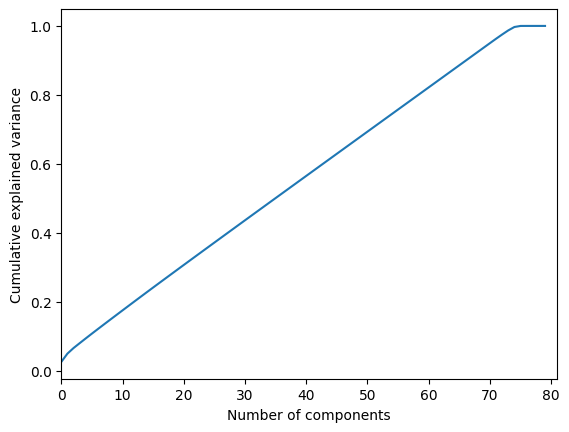

In [101]:
#apply PCA for feature contribution
x = X_train.values
x= np.asarray(x)

#impute missing values in x
imputer = SimpleImputer(strategy = "median")
X_imputed= imputer.fit_transform(x)

#standardize X_imputed
X_standardized = StandardScaler().fit_transform(X_imputed)
pca = PCA().fit(X_standardized)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,81)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()